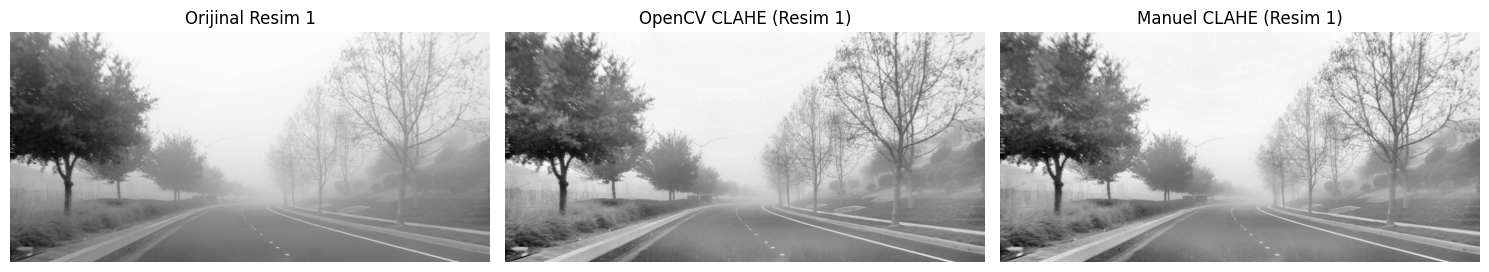

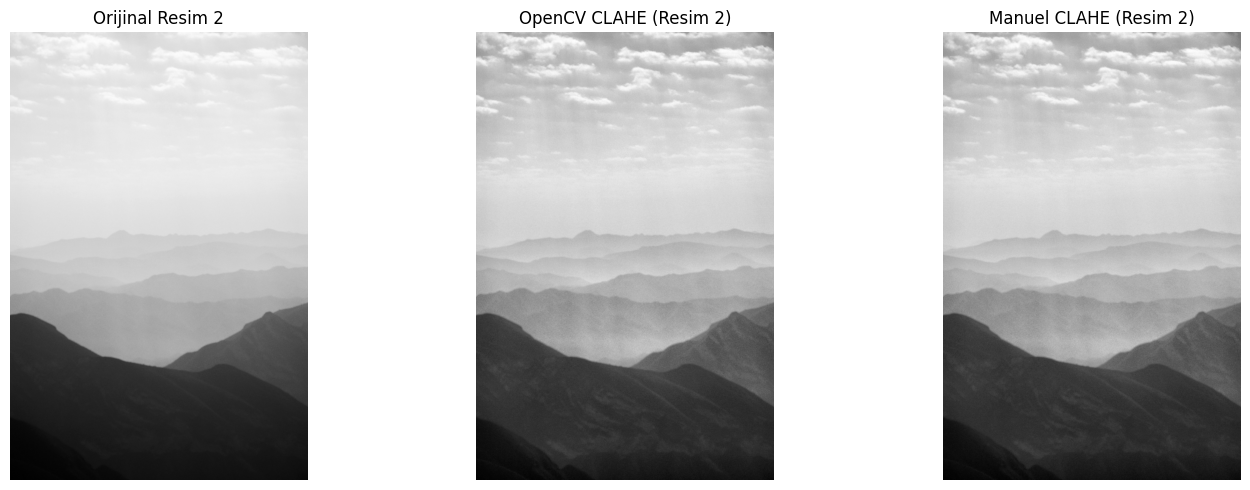

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clahe_opencv(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)

def manual_clahe(image, clip_limit=2.0, grid_size=(8, 8)):
    height, width = image.shape
    grid_h, grid_w = grid_size

    tile_h = height // grid_h
    tile_w = width // grid_w

    # 1. Her blok için kümülatif dağılım fonksiyonunu (CDF) hesapla
    histograms = np.zeros((grid_h, grid_w, 256), dtype=np.float32)
    for r in range(grid_h):
        for c in range(grid_w):
            tile = image[r*tile_h : (r+1)*tile_h, c*tile_w : (c+1)*tile_w]
            hist, _ = np.histogram(tile.flatten(), bins=256, range=(0, 256))

            # Kontrast Sınırlama (Clip Limit)
            if clip_limit > 0:
                limit = int(clip_limit * tile.size / 256)
                limit = max(limit, 1)
                clipped = np.clip(hist, 0, limit)
                clipped_sum = np.sum(hist - clipped)
                redistribution = clipped_sum // 256
                hist = clipped + redistribution

            # CDF Hesaplama
            cdf = hist.cumsum()
            cdf_normalized = (cdf - cdf.min()) * 255 / (tile.size - cdf.min() if (tile.size - cdf.min()) > 0 else 1)
            histograms[r, c] = np.clip(cdf_normalized, 0, 255)

    output = np.zeros_like(image, dtype=np.uint8)

    # 2. Bilineer Enterpolasyon ile pikselleri yeni değerlerine ata
    for y in range(height):
        for x in range(width):
            # Pikselin hangi hücre merkezleri arasında kaldığını bulalım
            ty = (y - tile_h / 2) / tile_h
            tx = (x - tile_w / 2) / tile_w

            r1 = int(np.floor(ty))
            c1 = int(np.floor(tx))

            r2 = r1 + 1
            c2 = c1 + 1

            # Sınır kontrolleri
            r1 = np.clip(r1, 0, grid_h - 1)
            c1 = np.clip(c1, 0, grid_w - 1)
            r2 = np.clip(r2, 0, grid_h - 1)
            c2 = np.clip(c2, 0, grid_w - 1)

            val = image[y, x]

            # Enterpolasyon ağırlıkları
            dy = ty - np.floor(ty)
            dx = tx - np.floor(tx)

            # Köşe/Kenar bölgelerinde doğrudan CDF değerini koru
            if (y < tile_h / 2 or y >= height - tile_h / 2) and (x < tile_w / 2 or x >= width - tile_w / 2):
                output[y, x] = histograms[r1, c1, val]
            elif y < tile_h / 2 or y >= height - tile_h / 2:
                # Sadece yatay enterpolasyon
                output[y, x] = (1 - dx) * histograms[r1, c1, val] + dx * histograms[r1, c2, val]
            elif x < tile_w / 2 or x >= width - tile_w / 2:
                # Sadece dikey enterpolasyon
                output[y, x] = (1 - dy) * histograms[r1, c1, val] + dy * histograms[r2, c1, val]
            else:
                # Bilineer enterpolasyon
                val_r1 = (1 - dx) * histograms[r1, c1, val] + dx * histograms[r1, c2, val]
                val_r2 = (1 - dx) * histograms[r2, c1, val] + dx * histograms[r2, c2, val]
                output[y, x] = (1 - dy) * val_r1 + dy * val_r2

    return output

# Resimleri test edelim
paths = ['/content/resim1.jpeg', '/content/resim 2.jpeg']

for i, path in enumerate(paths, start=1):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Hata: {path} yüklenemedi!")
        continue

    # Boyutların tam bölünmesi için kırpma/yeniden boyutlandırma yapalım (Örn: 8x8 grid için)
    h, w = img.shape
    h_new = h - (h % 8)
    w_new = w - (w % 8)
    img_resized = cv2.resize(img, (w_new, h_new))

    # Hazır CLAHE
    img_clahe_cv = clahe_opencv(img_resized, clip_limit=2.0, tile_grid_size=(8, 8))

    # Manuel CLAHE
    img_clahe_manual = manual_clahe(img_resized, clip_limit=2.0, grid_size=(8, 8))

    # Görselleştirme
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_resized, cmap='gray')
    plt.title(f'Orijinal Resim {i}')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_clahe_cv, cmap='gray')
    plt.title(f'OpenCV CLAHE (Resim {i})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img_clahe_manual, cmap='gray')
    plt.title(f'Manuel CLAHE (Resim {i})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()